# Projeto A3 - Analise exploratoria e pre-processamento

**Problema:** prever se um cliente de telecomunicacoes cancelara o servico.

**Target:** `Churn`, onde `Yes` indica cancelamento e `No` indica permanencia.

Nesta etapa, vamos conhecer a base, corrigir problemas nos dados e preparar
conjuntos de treino e teste. A modelagem sera feita na proxima etapa.

## Tecnica: importacao e configuracao das bibliotecas

Este bloco importa as ferramentas utilizadas no projeto:

- `pandas` e `numpy`: manipulacao e analise de dados;
- `matplotlib` e `seaborn`: criacao de graficos para a EDA;
- componentes do `scikit-learn`: separacao dos dados e pre-processamento.

O `RANDOM_STATE` fixa a aleatoriedade para que a divisao dos dados possa ser
reproduzida em outras execucoes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Carregamento dos dados

O caminho abaixo funciona ao executar o notebook tanto na raiz do projeto
quanto dentro da pasta `notebooks`.

**Tecnica utilizada:** leitura de dados tabulares com `pandas`.

O CSV e carregado em um DataFrame, estrutura que permite filtrar, transformar
e analisar as linhas e colunas da base.

In [2]:
possiveis_caminhos = [
    Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
]

caminho_dados = next((p for p in possiveis_caminhos if p.exists()), None)
if caminho_dados is None:
    raise FileNotFoundError("Arquivo CSV nao encontrado na pasta data.")

df = pd.read_csv(caminho_dados)
print(f"Dimensoes da base: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

Dimensoes da base: 7043 linhas e 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cada linha representa um cliente. As features descrevem perfil, servicos
contratados, forma de pagamento e valores cobrados.

**Tecnica utilizada:** inspecao estrutural dos dados.

`info()` mostra tipos e valores preenchidos. `describe()` gera estatisticas
descritivas, ajudando a identificar escalas, categorias e possiveis problemas.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Verificacao da qualidade dos dados

`TotalCharges` deveria ser numerica, mas foi carregada como texto porque
possui espacos vazios. Esses espacos serao convertidos em valores ausentes.

**Tecnica utilizada:** limpeza e conversao de tipos.

Tambem verificamos duplicatas e valores ausentes. O parametro
`errors="coerce"` transforma valores invalidos em `NaN`, permitindo que eles
sejam tratados corretamente no pipeline.

In [5]:
print("Linhas duplicadas:", df.duplicated().sum())
print("Valores ausentes antes da conversao:", df.isna().sum().sum())
print("Espacos vazios em TotalCharges:", df["TotalCharges"].str.strip().eq("").sum())

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Valores ausentes depois da conversao:")
df.isna().sum()[df.isna().sum() > 0]

Linhas duplicadas: 0
Valores ausentes antes da conversao: 0
Espacos vazios em TotalCharges: 11
Valores ausentes depois da conversao:


TotalCharges    11
dtype: int64

Os valores ausentes de `TotalCharges` serao preenchidos pela mediana dentro
do pipeline. Isso evita usar informacoes do conjunto de teste durante o
treinamento.

## 3. Analise do target

A base possui mais clientes que permaneceram do que clientes que cancelaram.
Portanto, alem da acuracia, sera importante avaliar recall e F1-score.

**Tecnica utilizada:** analise de distribuicao da variavel alvo.

A contagem absoluta mostra quantos clientes existem em cada classe, enquanto
a proporcao revela o desbalanceamento. Isso orienta a escolha das metricas de
avaliacao usadas posteriormente.

In [6]:
contagem_churn = df["Churn"].value_counts()
percentual_churn = df["Churn"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({"Quantidade": contagem_churn, "Percentual": percentual_churn})

,Quantidade,Percentual
Churn,,
No,5174,73.46
Yes,1869,26.54


**Tecnica utilizada:** grafico de contagem.

O grafico facilita a comparacao visual entre as classes `Yes` e `No`. Ele
evidencia que prever sempre a classe majoritaria poderia gerar uma acuracia
aparentemente boa, mas sem identificar adequadamente os churns.

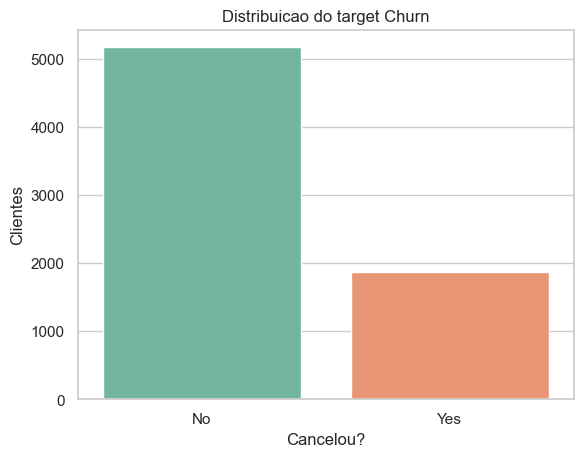

In [7]:
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
ax.set(title="Distribuicao do target Churn", xlabel="Cancelou?", ylabel="Clientes")
plt.show()

## 4. Relacao das features com churn

Os graficos abaixo ajudam a identificar perfis com maior proporcao de
cancelamento. A altura representa a taxa media de churn em cada categoria.

**Tecnica utilizada:** analise bivariada com graficos de barras.

O target e temporariamente convertido para 0 e 1. Assim, a media de
`ChurnNumerico` em cada categoria representa diretamente a taxa de churn.

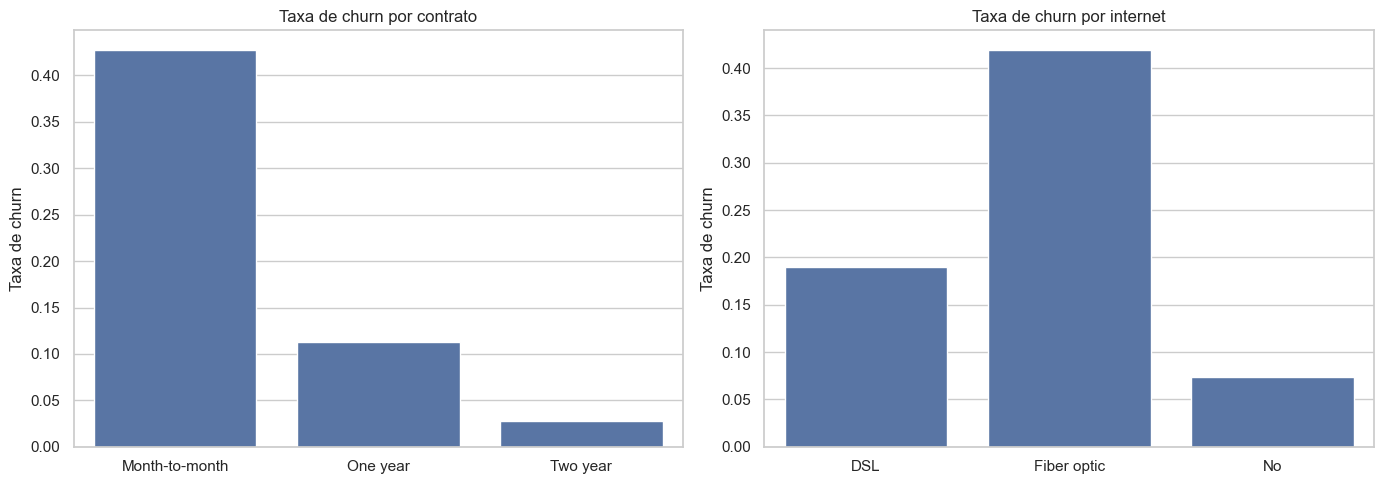

In [8]:
df_eda = df.copy()
df_eda["ChurnNumerico"] = df_eda["Churn"].map({"No": 0, "Yes": 1})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_eda, x="Contract", y="ChurnNumerico", ax=axes[0], errorbar=None)
sns.barplot(
    data=df_eda,
    x="InternetService",
    y="ChurnNumerico",
    ax=axes[1],
    errorbar=None,
)
axes[0].set(title="Taxa de churn por contrato", ylabel="Taxa de churn", xlabel="")
axes[1].set(title="Taxa de churn por internet", ylabel="Taxa de churn", xlabel="")
plt.tight_layout()
plt.show()

**Tecnica utilizada:** boxplot para comparar distribuicoes numericas.

O boxplot resume mediana, dispersao e valores extremos. Ele permite comparar
o tempo como cliente (`tenure`) e a cobranca mensal entre clientes que
cancelaram e clientes que permaneceram.

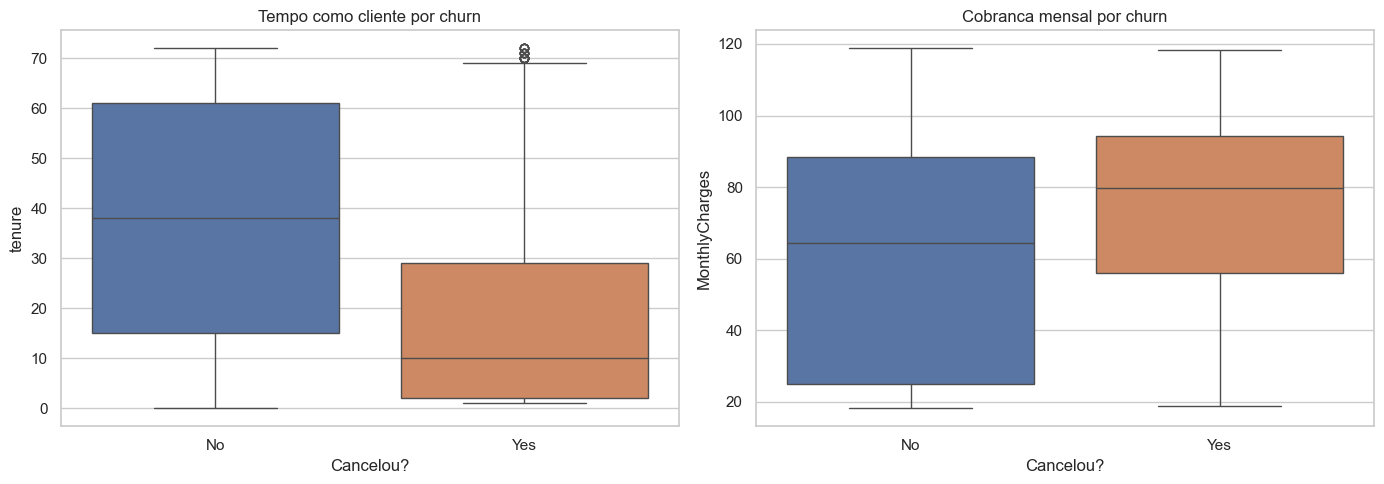

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], hue="Churn", legend=False)
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    ax=axes[1],
    hue="Churn",
    legend=False,
)
axes[0].set(title="Tempo como cliente por churn", xlabel="Cancelou?")
axes[1].set(title="Cobranca mensal por churn", xlabel="Cancelou?")
plt.tight_layout()
plt.show()

**Interpretacao inicial:** clientes com contrato mensal, menor tempo de
permanencia e determinadas modalidades de internet aparentam apresentar
maior risco de churn. Essa observacao devera ser confirmada pelos modelos.

## 5. Separacao entre features e target

`customerID` e apenas um identificador e nao ajuda a explicar o churn.
O target e transformado em 0 e 1 para uso pelos classificadores.

**Tecnica utilizada:** divisao estratificada entre treino e teste.

Os dados de treino ensinam os modelos, enquanto os dados de teste simulam
clientes ainda nao vistos. `stratify=y` preserva a proporcao de churn nos
dois conjuntos, e `random_state` torna a divisao reproduzivel.

In [10]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nProporcao de churn no treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporcao de churn no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: (5634, 19) | Teste: (1409, 19)

Proporcao de churn no treino:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Proporcao de churn no teste:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


A separacao estratificada preserva aproximadamente a mesma proporcao de
churn nos conjuntos de treino e teste.

## 6. Pipeline de pre-processamento

- Features numericas: valores ausentes preenchidos pela mediana e
  padronizacao com `StandardScaler`.
- Features categoricas: valor mais frequente para ausentes e codificacao
  one-hot.

O pipeline sera ajustado apenas durante o treinamento de cada modelo.

**Tecnicas utilizadas:**

- **Imputacao pela mediana:** preenche valores numericos ausentes e sofre
  menos influencia de valores extremos;
- **Padronizacao:** transforma variaveis numericas para escalas comparaveis,
  importante principalmente para KNN e SVM;
- **One-hot encoding:** converte categorias em colunas binarias sem criar uma
  ordem artificial entre elas;
- **ColumnTransformer:** aplica tecnicas diferentes conforme o tipo da coluna;
- **Pipeline:** organiza as etapas e ajuda a evitar vazamento de dados.

In [11]:
colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

pipeline_numerico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="median")),
        ("padronizacao", StandardScaler()),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessador = ColumnTransformer(
    transformers=[
        ("numerico", pipeline_numerico, colunas_numericas),
        ("categorico", pipeline_categorico, colunas_categoricas),
    ]
)

print("Colunas numericas:", colunas_numericas)
print("Quantidade de colunas categoricas:", len(colunas_categoricas))

Colunas numericas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Quantidade de colunas categoricas: 15


## 7. Verificacao do pre-processamento

Esta transformacao e feita somente para verificar o resultado. Na etapa de
modelagem, o `preprocessador` sera combinado com cada classificador em um
unico pipeline.

`fit_transform` aprende os parametros usando apenas o treino e transforma os
dados. No teste usamos somente `transform`, evitando que informacoes do teste
influenciem o aprendizado.

In [12]:
X_train_transformado = preprocessador.fit_transform(X_train)
X_test_transformado = preprocessador.transform(X_test)

print("Formato original do treino:", X_train.shape)
print("Formato transformado do treino:", X_train_transformado.shape)
print("Formato transformado do teste:", X_test_transformado.shape)
print("Valores ausentes apos o pre-processamento:", np.isnan(X_train_transformado.data).sum())

Formato original do treino: (5634, 19)
Formato transformado do treino: (5634, 45)
Formato transformado do teste: (1409, 45)
Valores ausentes apos o pre-processamento: 0


## Conclusao da etapa

A base foi analisada e preparada para modelagem. Corrigimos `TotalCharges`,
removemos o identificador, separamos treino e teste de forma estratificada e
criamos um pipeline reutilizavel de pre-processamento.

**Proxima etapa:** treinar e avaliar KNN, Naive Bayes, SVM e Arvore de
Decisao, seguidos pelo comite de classificadores.